In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
dataset=pd.read_csv("50_Startups.csv")

In [36]:
dataset

,RandD Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156994.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.85,311613.28,New York,152211.77
9,94657.16,145077.58,282574.31,New York,125370.37


In [37]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [38]:
dataset

,RandD Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156994.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.85,311613.28,152211.77,0,1
9,94657.16,145077.58,282574.31,125370.37,0,1


In [39]:
dataset.columns

Index(['RandD Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [40]:
Independent=dataset[['RandD Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]
      

In [41]:
Independent

,RandD Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.85,311613.28,0,1
9,94657.16,145077.58,282574.31,0,1


In [42]:
dependent=dataset[["Profit"]]

In [43]:
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156994.12
6,156122.51
7,155752.60
8,152211.77
9,125370.37


In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(Independent,dependent,test_size=0.30,random_state=0)

In [45]:
x_train

,RandD Spend,Administration,Marketing Spend,State_Florida,State_New York
18,86419.70,153514.11,0.00,0,1
19,76253.86,113867.30,298664.47,0,0
16,94657.16,145077.58,282574.31,0,1
1,162597.70,151377.59,443898.53,0,0
10,91749.16,114175.79,294919.57,1,0
25,75328.87,144135.98,134050.07,1,0
24,64664.71,139553.16,137962.62,0,0
8,120542.52,148718.85,311613.28,0,1
6,134615.46,147198.87,127716.82,0,0
4,142107.34,91391.77,366168.42,1,0


In [46]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [47]:
x_train

array([[-0.54250646,  1.23113842, -2.32102105, -0.70710678,  1.25356634],
       [-0.84995648, -0.8294321 ,  0.22216647, -0.70710678, -0.79772404],
       [-0.2933773 ,  0.79266518,  0.08515555, -0.70710678,  1.25356634],
       [ 1.76137862,  1.12009669,  1.45886345, -0.70710678, -0.79772404],
       [-0.38132524, -0.8133989 ,  0.1902779 ,  1.41421356, -0.79772404],
       [-0.87793136,  0.74372724, -1.17955797,  1.41421356, -0.79772404],
       [-1.20045229,  0.50554355, -1.14624183, -0.70710678, -0.79772404],
       [ 0.48948514,  0.98191354,  0.33242817, -0.70710678,  1.25356634],
       [ 0.91509931,  0.90291535, -1.23348686, -0.70710678, -0.79772404],
       [ 1.14167956, -1.99755671,  0.79697606,  1.41421356, -0.79772404],
       [-0.2933773 ,  0.79266518,  0.08515555, -0.70710678,  1.25356634],
       [ 0.78452838,  0.816182  ,  0.43685346,  1.41421356, -0.79772404],
       [-0.82605962, -1.58751073, -1.12399851, -0.70710678,  1.25356634],
       [ 1.21018308, -0.57972439,  0.9

In [48]:
scy=StandardScaler()
y_train=scy.fit_transform(y_train)
y_test=scy.transform(y_test)

In [54]:
from sklearn.svm import SVR
regressor=SVR(kernel="linear",C=100)
regressor.fit(x_train,y_train)

C:\Users\SPPSS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [55]:
y_pred=regressor.predict(x_test)

In [56]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [57]:
r_score

0.9535465712927123

In [58]:
import pickle 
filename="Finalized_model_SVM_preproinout.sav"
pickle.dump(regressor,open(filename,'wb'))

In [59]:
preinput=sc.transform([[1300,12000,4000,0,1]])

C:\Users\SPPSS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [60]:
preinput

array([[-3.11681935, -6.12379891, -2.28696025, -0.70710678,  1.25356634]])

In [61]:
loaded_model=pickle.load(open("Finalized_model_SVM_preproinout.sav",'rb'))

In [62]:
result=loaded_model.predict(preinput)
result

array([-3.05596489])

In [25]:
preoutput=scy.inverse_transform([result])
preoutput
                               

array([[47830.1403135]])

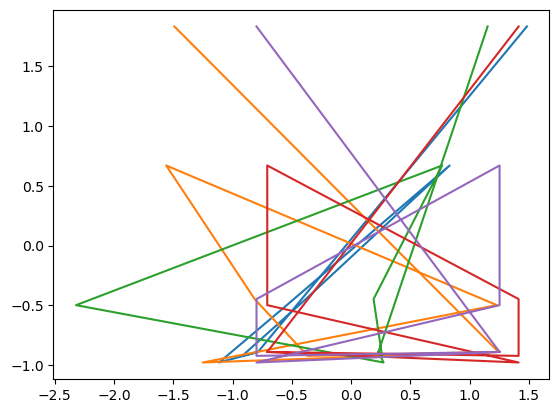

In [33]:

plt.plot(x_test, y_test)
plt.show()